In [40]:
import os
import time
import json
import shutil
import numpy as np
from pathlib import Path
from PIL import Image
from pprint import pprint
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage

# lerobot
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.datasets.dataset_tools import add_feature
from lerobot.constants import OBS_ENV_STATE 

# gemini
from google import genai

# my code
from src.paths import REPO_ROOT, DATASETS_DIR, HF_NAME
from gemini.gemini_utils import call_gemini_robotics_er, compute_center_angle, GEMINI_ID

# set up env secrets
from dotenv import load_dotenv
load_dotenv(REPO_ROOT/".env", override=True)

# magic autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In this notebook we will add environment state `OBS_ENV_STATE` to the dataset for training. This vector will include the `[x_px, y_px, theta_deg]` position of the car, as annotated by Gemini.

This will be later used for training a model with this additional data.

#### 1. Load Dataset & define new feature

In [ ]:
REPO_NAME     = 'so101_car_pick_and_place'
PUSH_TO_HUB   = True

Metadata for new feature:

In [3]:
new_feature_name = OBS_ENV_STATE
new_feature_meta = {
    "dtype": "float32",
    "names": [
        "x_px",
        "y_px",
        "rotation_deg"
    ],
    "shape":[
        3
    ]
}

#### 2. Define prompt to be used
This should be updated according to the scenario \ dataset.

In [39]:
from gemini.gemini_prompts import YELLOW_CAR_PROMPT as PROMPT
pprint(PROMPT)

('Locate the yellow school bus toy in the image. Identify two specific points '
 'along its long axis: 1. The FRONT of the bus. 2. The REAR of the bus. Return '
 'your response as JSON in this format: [{"front_point": [y, x], "rear_point": '
 '[y, x]}]Coordinates must be normalized between 0 and 1000.')


#### 3. Connect to Gemini & Test

In [ ]:
client = genai.Client(api_key=os.getenv('GOOGLE_API_KEY'))
print(
    client.models.generate_content(
        model=GEMINI_ID, contents="Are you there?"
    ).text
)

Yes, I am here. How can I help you?


#### 4. Build dataset

In [7]:
ds = LeRobotDataset(
    repo_id = f"{HF_NAME}/{REPO_NAME}",
    root = DATASETS_DIR / REPO_NAME,
    download_videos = False
)

# create annotation dir
ann_dir = Path(ds.root) / "annotation"
ann_dir.mkdir(parents=True, exist_ok=True)
ann_path = ann_dir / "annotations.json"

Call Gemini once per episode using the 1st image

#### 5. Generate annotations with Gemini call

In [8]:
annotation_data = []
new_feature_data = np.zeros((len(ds), ), dtype=object)

for ep, start_idx in enumerate(ds.meta.episodes['dataset_from_index']):
    end_idx = ds.meta.episodes['dataset_to_index'][ep]
    sample = ds[start_idx]
    img = ToPILImage()(sample["observation.images.top_cam"])

    # Gemini call
    t0 = time.time()
    
    # add a loop to retry api calls
    while True: 
        try:
            out = call_gemini_robotics_er(client, GEMINI_ID, img, PROMPT)
            res = json.loads(out)[0]
            # compute geometry
            x_px, y_px, theta_deg, annotated = compute_center_angle(res, 'front_point', 'rear_point', img)
            break

        # rate errors mostly
        except Exception as e:
            msg = str(e)
            print(f"failed at episode {ep} with {msg}")
            if "RESOURCE_EXHAUSTED" in msg or "429" in msg or "quota" in msg.lower():
                wait = 60
                print(f"Quota hit. Waiting {wait}s before retrying...")
                time.sleep(wait)
                continue
            else:
                res = None
                break

    # write the same data to all frames in the episode
    vec = np.array([float(x_px), float(y_px), float(theta_deg)], dtype=np.float32)
    # new_feature_data[start_idx:end_idx] = np.tile([vec], (end_idx - start_idx, 1))
    for i in range(start_idx, end_idx):
        new_feature_data[i] = vec.copy()  

    # record to .json
    annotation_data.append({
        "episode": int(ep),
        "x_px": float(x_px), "y_px": float(y_px), "theta_deg": float(theta_deg),
        "front_point_norm": res["front_point"],
        "rear_point_norm": res["rear_point"],
        "latency_s": round(time.time() - t0, 4),
        "frame_range": [int(start_idx), int(end_idx)]
    })

    # save data
    annotated.save(ann_dir / f"ep_{ep:03d}_annotation.jpg")
    with open(ann_path, "w") as f:
        json.dump(
            annotation_data,
            f,
            indent=2
        )


failed at episode 11 with 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 10\nPlease retry in 7.08034182s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'model': 'gemini-robotics-er-1.5-preview', 'location': 'global'}, 'quotaValue': '10'}]}, {'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc

TODO temporary only if doing part of the episodes

In [ ]:
# for idx, element in enumerate(new_feature_data):
#     if not isinstance (element, np.ndarray) or element.shape != (3,):
#         new_feature_data[idx] = new_feature_data[0].copy()

#### 6. Sample Results

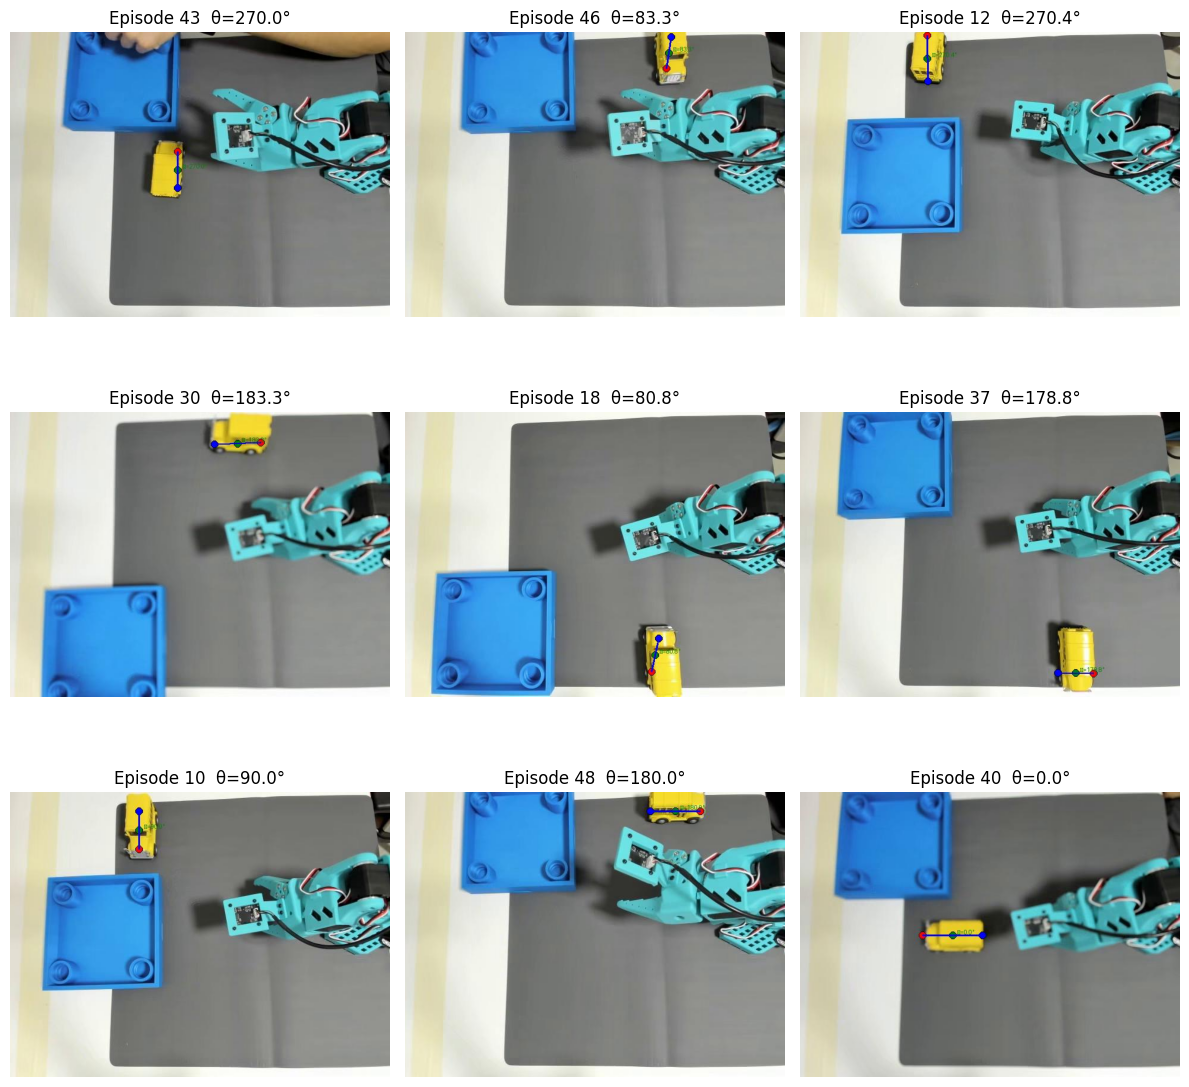

In [10]:
# load annotation summary
with open(ann_path, "r") as f:
    summary = json.load(f)

# pick up to 9 random annotated episodes
N = min(9, len(summary))
sampled = np.random.choice(summary, 9)

cols = 3
rows = (N + cols - 1) // cols  # auto number of rows
plt.figure(figsize=(12, 4 * rows))

for i, rec in enumerate(sampled):
    ep = rec["episode"]
    theta = rec["theta_deg"]
    img_path = ann_dir / f"ep_{ep:03d}_annotation.jpg"
    if not img_path.exists():
        continue

    img = Image.open(img_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Episode {ep}  θ={theta:.1f}°")

plt.tight_layout()
plt.show()

#### 7. Append to Dataset

In [ ]:
# convert to per-row object array (each element is np.ndarray((3,), np.float32))
new_ds = add_feature(
    ds,
    feature_name   = new_feature_name,
    feature_values = new_feature_data,
    feature_info   = new_feature_meta,
    output_dir     = ds.root.parent / f"{REPO_NAME}_modified",
    repo_id        = ds.repo_id
)

Copying observation.images.top_cam videos: 100%|██████████| 1/1 [00:00<00:00,  6.43it/s]
Generating train split: 49 examples [00:00, 4380.43 examples/s]
Generating train split: 36324 examples [00:00, 4304268.80 examples/s]


In [27]:
shutil.copytree(ds.root / "annotation", new_ds.root / "annotation", dirs_exist_ok=True)

PosixPath('/home/jonathan/Github/IDC_Project-Sim_Real_Sim/datasets/so101_car_pick_and_place_modified/annotation')

In [32]:
if PUSH_TO_HUB:
    os.system(f"hf auth login --token {os.getenv('HUGGINGFACE_TOKEN')}")
new_ds.push_to_hub()

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `pc` has been saved to /home/jonathan/.cache/huggingface/stored_tokens
Your token has been saved to /home/jonathan/.cache/huggingface/token
Login successful.
The current active token is: `pc`
Processing Files (54 / 54): 100%|██████████|  462MB /  462MB, 3.87MB/s  
New Data Upload: 100%|██████████|  151MB /  151MB, 3.87MB/s  


In [50]:
pprint(new_ds.features['action'])
pprint(new_ds.features[OBS_ENV_STATE])

{'dtype': 'float32',
 'names': ['shoulder_pan.pos',
           'shoulder_lift.pos',
           'elbow_flex.pos',
           'wrist_flex.pos',
           'wrist_roll.pos',
           'gripper.pos'],
 'shape': (6,)}
{'dtype': 'float32', 'names': ['x_px', 'y_px', 'rotation_deg'], 'shape': (3,)}
